In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sumo_rl
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from sumo_rl.environment.observations import ObservationFunction
from gymnasium import spaces

In [2]:
# Hyperparameters
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.95
batch_size = 64
learning_rate = 1e-3
num_seconds=1000
episodes = 50

In [3]:
def priority_reward_fn(ts):
    """
    Custom reward function that heavily penalizes stopped ambulances and buses.
    ts: The TrafficSignal object provided by sumo_rl.
    """
    reward = 0
    # Access the TraCI connection directly through the traffic signal
    traci = ts.sumo 
    
    # Iterate through all incoming lanes controlled by this specific traffic light
    for lane in ts.lanes:
        # Get the IDs of all vehicles currently on this lane
        vehicles = traci.lane.getLastStepVehicleIDs(lane)
        
        for veh in vehicles:
            # Get the vehicle's current speed
            speed = traci.vehicle.getSpeed(veh)
            
            # If the vehicle is practically stopped (waiting at a red light)
            if speed < 0.1:
                # Retrieve the vehicle type (defined in our .rou.xml file)
                v_type = traci.vehicle.getTypeID(veh)
                
                # Apply custom penalty weights
                if v_type == "ambulance":
                    reward -= 50.0  # Massive penalty for delaying an ambulance
                elif v_type == "bus":
                    reward -= 5.0   # Moderate penalty for delaying a bus
                else:
                    reward -= 1.0   # Standard penalty for normal cars
                    
    return reward

In [4]:
class PriorityObservationFunction(ObservationFunction):
    def __init__(self, ts):
        super().__init__(ts)
        # We need to define the shape of our observation array.
        # Let's say: [density_N, density_S, density_E, density_W, emergency_present_N, emergency_present_S...]
        pass 

    def __call__(self):

        traci = self.ts.sumo
        obs = []
        
        # normal traffic density
        density = self.ts.get_lanes_density()
        obs.extend(density)
        
        # whether an ambulance is waiting on each lane
        for lane in self.ts.lanes:
            emergency_waiting = 0.0
            vehicles = traci.lane.getLastStepVehicleIDs(lane)
            for veh in vehicles:
                if traci.vehicle.getTypeID(veh) == "ambulance":
                    emergency_waiting = 1.0
                    break
            obs.append(emergency_waiting)
            
        return np.array(obs, dtype=np.float32)

    def observation_space(self):
        return spaces.Box(low=0., high=1., shape=(len(self.ts.lanes) * 2,), dtype=np.float32)

In [5]:
# Initialize PettingZoo environment

my_routes = "./env/3x3_priority/vtypes.add.xml, ./env/3x3_priority/cars.rou.xml, ./env/3x3_priority/buses.rou.xml, ./env/3x3_priority/bikes.rou.xml, ./env/3x3_priority/ambulance.rou.xml"

env = sumo_rl.parallel_env(
    net_file="./env/3x3_priority/3x3Grid2lanes.net.xml",
    route_file=my_routes,
    reward_fn=priority_reward_fn,
    observation_class=PriorityObservationFunction,
    use_gui=False, # Keep False for training
    num_seconds=num_seconds,
    delta_time=5,
    sumo_warnings = False
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 31ms, vehicles TOT 0 ACT 0 BUF 0)                     


In [6]:
# Get dimensions for the network
sample_agent = env.possible_agents[0]
obs_dim = env.observation_space(sample_agent).shape[0]
action_dim = env.action_space(sample_agent).n

In [7]:
print(obs_dim)
print(action_dim)

16
4


In [8]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [9]:
# Initialize Network, Optimizer, and Buffer
q_net = QNetwork(obs_dim, action_dim)
optimizer = optim.Adam(q_net.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()
replay_buffer = deque(maxlen=10000)

In [10]:
all_episode_rewards = []

for episode in range(episodes):
    observations, infos = env.reset()
    episode_reward = 0
    
    while env.agents:
        actions = {}
        
        # Epsilon-Greedy Action Selection 
        for agent in env.agents:
            obs_tensor = torch.FloatTensor(observations[agent]).unsqueeze(0)
            
            if random.random() < epsilon:
                # Explore
                actions[agent] = env.action_space(agent).sample()
            else:
                # Exploit
                with torch.no_grad():
                    q_values = q_net(obs_tensor)
                    actions[agent] = torch.argmax(q_values).item()

        # Step the Environment
        next_observations, rewards, terminations, truncations, infos = env.step(actions)

        # Store Transitions in Shared Buffer
        for agent in env.agents:
            replay_buffer.append((
                observations[agent], 
                actions[agent], 
                rewards[agent], 
                next_observations[agent], 
                terminations[agent] or truncations[agent]
            ))
            episode_reward += rewards[agent]

        observations = next_observations

        # Train the Q-Network 
        if len(replay_buffer) > batch_size:
            # Sample a batch
            batch = random.sample(replay_buffer, batch_size)
            b_obs, b_act, b_rew, b_next_obs, b_done = zip(*batch)
            
            b_obs = torch.FloatTensor(np.array(b_obs))
            b_act = torch.LongTensor(b_act).unsqueeze(1)
            b_rew = torch.FloatTensor(b_rew).unsqueeze(1)
            b_next_obs = torch.FloatTensor(np.array(b_next_obs))
            b_done = torch.FloatTensor(b_done).unsqueeze(1)

            # Compute Current Q values
            current_q = q_net(b_obs).gather(1, b_act)
            
            # Compute Target Q values
            with torch.no_grad():
                max_next_q = q_net(b_next_obs).max(1)[0].unsqueeze(1)
                target_q = b_rew + (gamma * max_next_q * (1 - b_done))
            
            # Optimize
            loss = loss_fn(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    all_episode_rewards.append(episode_reward)

    # Decay Epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    print(f"Episode {episode + 1} | Total Shared Reward: {episode_reward:.2f} | Epsilon: {epsilon:.2f}")

env.close()

 Retrying in 1 seconds
Episode 1 | Total Shared Reward: -7077.00 | Epsilon: 0.95
Step #1000.00 (1ms ~= 1000.00*RT, ~108000.00UPS, TraCI: 86ms, vehicles TOT 462 ACT 108 BUF 
 Retrying in 1 seconds
Episode 2 | Total Shared Reward: -5732.00 | Epsilon: 0.90
Step #1000.00 (1ms ~= 1000.00*RT, ~92000.00UPS, TraCI: 99ms, vehicles TOT 462 ACT 92 BUF 0)
 Retrying in 1 seconds
Episode 3 | Total Shared Reward: -6252.00 | Epsilon: 0.86
Step #1000.00 (1ms ~= 1000.00*RT, ~98000.00UPS, TraCI: 112ms, vehicles TOT 462 ACT 98 BUF 0
 Retrying in 1 seconds
Episode 4 | Total Shared Reward: -6963.00 | Epsilon: 0.81
Step #1000.00 (1ms ~= 1000.00*RT, ~98000.00UPS, TraCI: 93ms, vehicles TOT 462 ACT 98 BUF 0)
 Retrying in 1 seconds
Episode 5 | Total Shared Reward: -6881.00 | Epsilon: 0.77
Step #1000.00 (0ms ?*RT. ?UPS, TraCI: 106ms, vehicles TOT 462 ACT 99 BUF 0)                
 Retrying in 1 seconds
Episode 6 | Total Shared Reward: -5518.00 | Epsilon: 0.74
Step #1000.00 (0ms ?*RT. ?UPS, TraCI: 70ms, vehicles T

In [11]:
model_path = "./models/3x3-v3.pth"
torch.save(q_net.state_dict(), model_path)

In [12]:
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    
    plt.plot(rewards, label='Episode Reward', color='dodgerblue', alpha=0.75)
    
    plt.title('Independent DQN Training over 3x3 SUMO Grid')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.savefig('training_curve.png')
    plt.show()

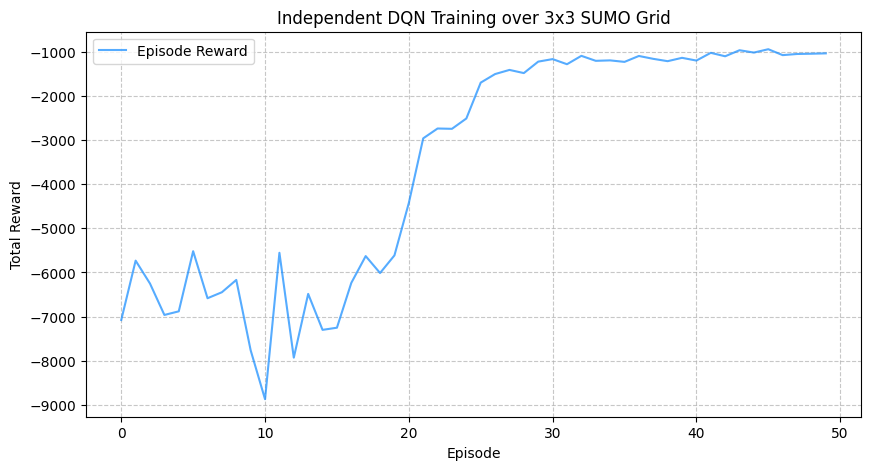

In [13]:
plot_rewards(all_episode_rewards)

In [16]:
def evaluate_model(model_path):
      
    my_routes = "./env/3x3_priority/vtypes.add.xml, ./env/3x3_priority/cars.rou.xml, ./env/3x3_priority/buses.rou.xml, ./env/3x3_priority/bikes.rou.xml, ./env/3x3_priority/ambulance.rou.xml"
    
    env = sumo_rl.parallel_env(
        net_file="./env/3x3_priority/3x3Grid2lanes.net.xml",
        route_file=my_routes,
        reward_fn=priority_reward_fn,
        observation_class=PriorityObservationFunction,
        use_gui=True, # Keep False for training
        num_seconds=num_seconds,
        delta_time=5,
    )

    # Load the Trained Model
    q_net = QNetwork(obs_dim, action_dim)
    try:
        q_net.load_state_dict(torch.load(model_path))
        print("Model loaded successfully!")
    except FileNotFoundError:
        print("Error: Could not find the model.")
        return

    # Set network to evaluation modee
    q_net.eval() 

    # Run the Simulation Loop
    observations, infos = env.reset()
    total_evaluation_reward = 0
    
    while env.agents:
        actions = {}
        
        # Pure Exploitation Loop (Epsilon = 0)
        for agent in env.agents:
            obs_tensor = torch.FloatTensor(observations[agent]).unsqueeze(0)
            
            # Disable gradient calculation to save memory and speed up inference
            with torch.no_grad():
                q_values = q_net(obs_tensor)
                # Always pick the action with the highest Q-value
                actions[agent] = torch.argmax(q_values).item() 

        # Step the environment
        observations, rewards, terminations, truncations, infos = env.step(actions)

        # Track the total reward to see how well it did
        for agent in env.agents:
            total_evaluation_reward += rewards[agent]

    print(f"Simulation Finished. Final Total Reward: {total_evaluation_reward:.2f}")
    env.close()

In [17]:
evaluate_model(model_path)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 31ms, vehicles TOT 0 ACT 0 BUF 0)                     
Model loaded successfully!
 Retrying in 1 seconds
Simulation Finished. Final Total Reward: -857.00


In [18]:
env.close()